## Configuração do Ambiente e Importações
---

In [ ]:
!pip install langdetect

In [ ]:
# Bibliotecas Padrão do Python
import re
import warnings

# Bibliotecas de Terceiros (Core Data Science & ML)
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from langdetect import LangDetectException, detect

# Módulos Específicos do Scikit-learn e NLTK
# Pré-processamento e Features
from nltk.corpus import stopwords
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
# Divisão de Dados e Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
# Modelos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
# Métricas de Avaliação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Comando mágico para renderizar gráficos no notebook
%matplotlib inline

# Configurações de exibição do Pandas e Seaborn
pd.set_option('display.max_colwidth', 200)
sns.set_style('whitegrid')
sns.set_palette('viridis')

# Suprimir avisos para uma saída mais limpa
warnings.filterwarnings('ignore')


# Downloads de Pacotes de PLN
# (Executa o download apenas se os recursos não estiverem presentes)
try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

print("Ambiente configurado e bibliotecas importadas com sucesso.")

Ambiente configurado e bibliotecas importadas com sucesso.


## Carregamento e Análise Exploratória dos Dados
---

In [ ]:
# Carrega o dataset completo a partir da URL.
df = pd.read_csv('https://raw.githubusercontent.com/turing-usp/fernando-pessoa/refs/heads/master/fernando_pessoa.csv')
df.head()

,id,autor,titulo,tipo,texto,data,bibliografia
0,4,Ricardo Reis,Diana através dos ramos,poesia,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",16-6-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 70."
1,5,Fernando Pessoa,A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS,prosa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",10-3-1933,"Páginas de Pensamento Político. Vol II. Fernando Pessoa. (Introdução, organização e notas de António Quadros.) Mem Martins: Europa-América, 1986.\n\- 201."
2,6,Fernando Pessoa,The Infinite is then the Possible,prosa,The Infinite is then the Possible.\nHow does this possible realise itself? How is it realised?\nIt is realised by numbers. But by how many numbers? By an infinite number of numbers (let the expres...,1906?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 58."
3,7,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,",poesia,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",11-8-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 71."
4,8,Fernando Pessoa,"If evolution is to be universally true,",prosa,"If evolution is to be universally true, itself it must evolute. But if it must evolute evolution is no longer universally true, for it changes, for it ceases to be evolution.\nSince things are by ...",1907?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 60."


In [ ]:
# Verifica o comprimento do DataFrame (num. linhas, num. colunas)
df.shape

(4530, 7)

In [ ]:
# Filtra o DataFrame para manter apenas os textos dos autores e heterônimos selecionados.
df = df[df['autor'].isin(['Alberto Caeiro', 'Álvaro de Campos', 'Ricardo Reis', 'Bernardo Soares', 'Fernando Pessoa'])]
df.head()

,id,autor,titulo,tipo,texto,data,bibliografia
0,4,Ricardo Reis,Diana através dos ramos,poesia,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",16-6-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 70."
1,5,Fernando Pessoa,A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS,prosa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",10-3-1933,"Páginas de Pensamento Político. Vol II. Fernando Pessoa. (Introdução, organização e notas de António Quadros.) Mem Martins: Europa-América, 1986.\n\- 201."
2,6,Fernando Pessoa,The Infinite is then the Possible,prosa,The Infinite is then the Possible.\nHow does this possible realise itself? How is it realised?\nIt is realised by numbers. But by how many numbers? By an infinite number of numbers (let the expres...,1906?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 58."
3,7,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,",poesia,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",11-8-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 71."
4,8,Fernando Pessoa,"If evolution is to be universally true,",prosa,"If evolution is to be universally true, itself it must evolute. But if it must evolute evolution is no longer universally true, for it changes, for it ceases to be evolution.\nSince things are by ...",1907?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 60."


In [ ]:
# Verifica os valores presentes na coluna 'autor'
df['autor'].value_counts().index

Index(['Fernando Pessoa', 'Bernardo Soares', 'Álvaro de Campos',
       'Ricardo Reis', 'Alberto Caeiro'],
      dtype='object', name='autor')

In [ ]:
# Verifica o comprimento do DataFrame (num. linhas, num. colunas)
df.shape

(4149, 7)

In [ ]:
# Criação de colunas com metadados simples sobre o texto.
# Usar .str antes de funções de string é mais performático e seguro em pandas.
df['num_caracteres'] = df['texto'].str.len()
df['num_palavras'] = df['texto'].apply(lambda x: len(str(x).split()))
df.head()

,id,autor,titulo,tipo,texto,data,bibliografia,num_caracteres,num_palavras
0,4,Ricardo Reis,Diana através dos ramos,poesia,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",16-6-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 70.",212,34
1,5,Fernando Pessoa,A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS,prosa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",10-3-1933,"Páginas de Pensamento Político. Vol II. Fernando Pessoa. (Introdução, organização e notas de António Quadros.) Mem Martins: Europa-América, 1986.\n\- 201.",12212,2007
2,6,Fernando Pessoa,The Infinite is then the Possible,prosa,The Infinite is then the Possible.\nHow does this possible realise itself? How is it realised?\nIt is realised by numbers. But by how many numbers? By an infinite number of numbers (let the expres...,1906?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 58.",1873,341
3,7,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,",poesia,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",11-8-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 71.",226,40
4,8,Fernando Pessoa,"If evolution is to be universally true,",prosa,"If evolution is to be universally true, itself it must evolute. But if it must evolute evolution is no longer universally true, for it changes, for it ceases to be evolution.\nSince things are by ...",1907?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 60.",945,166


In [ ]:
#Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4149 entries, 0 to 4529
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              4149 non-null   int64 
 1   autor           4149 non-null   object
 2   titulo          4149 non-null   object
 3   tipo            4149 non-null   object
 4   texto           4149 non-null   object
 5   data            4113 non-null   object
 6   bibliografia    4134 non-null   object
 7   num_caracteres  4149 non-null   int64 
 8   num_palavras    4149 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 324.1+ KB


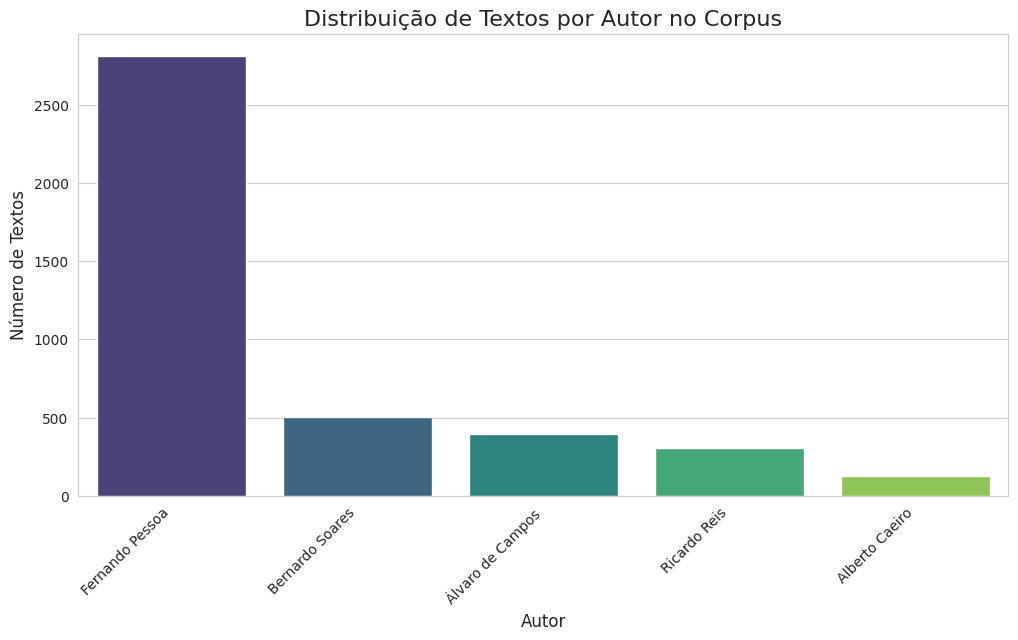

In [ ]:
# Análise da Variável Alvo
plt.figure(figsize=(12, 6))
sns.barplot(x=df['autor'].value_counts().index, y=df['autor'].value_counts().values, palette='viridis')
plt.title('Distribuição de Textos por Autor no Corpus', fontsize=16)
plt.xlabel('Autor', fontsize=12)
plt.ylabel('Número de Textos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

## Pré-processamento e Limpeza dos Textos
---

In [ ]:
# Definição da função para detecção de idioma
def detectar_idioma(texto):
    """Detecta o idioma de um texto, retornando 'desconhecido' para textos curtos."""
    try:
        # Garante que o texto tenha um comprimento mínimo para a detecção
        if pd.notna(texto) and len(str(texto).strip()) > 20:
            return detect(str(texto))
        else:
            return 'desconhecido' # Para textos muito curtos ou vazios
    except LangDetectException:
        return 'error'

In [ ]:
# Aplicação da função
df['idioma'] = df['texto'].apply(detectar_idioma)
df.head()

,id,autor,titulo,tipo,texto,data,bibliografia,num_caracteres,num_palavras,idioma
0,4,Ricardo Reis,Diana através dos ramos,poesia,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",16-6-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 70.",212,34,pt
1,5,Fernando Pessoa,A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS,prosa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",10-3-1933,"Páginas de Pensamento Político. Vol II. Fernando Pessoa. (Introdução, organização e notas de António Quadros.) Mem Martins: Europa-América, 1986.\n\- 201.",12212,2007,pt
2,6,Fernando Pessoa,The Infinite is then the Possible,prosa,The Infinite is then the Possible.\nHow does this possible realise itself? How is it realised?\nIt is realised by numbers. But by how many numbers? By an infinite number of numbers (let the expres...,1906?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 58.",1873,341,en
3,7,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,",poesia,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",11-8-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 71.",226,40,pt
4,8,Fernando Pessoa,"If evolution is to be universally true,",prosa,"If evolution is to be universally true, itself it must evolute. But if it must evolute evolution is no longer universally true, for it changes, for it ceases to be evolution.\nSince things are by ...",1907?,"Textos Filosóficos . Vol. II. Fernando Pessoa. (Estabelecidos e prefaciados por António de Pina Coelho.) Lisboa: Ática, 1968.\n\- 60.",945,166,en


In [ ]:
# Distribuição dos idiomas encontrados
df['idioma'].value_counts()

,count
idioma,
pt,3645
en,493
fr,9
ca,1
es,1


In [ ]:
# Mantém apenas os textos identificados como português ('pt').
df = df[df['idioma'] == 'pt']
df.head()

,id,autor,titulo,tipo,texto,data,bibliografia,num_caracteres,num_palavras,idioma
0,4,Ricardo Reis,Diana através dos ramos,poesia,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",16-6-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 70.",212,34,pt
1,5,Fernando Pessoa,A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS,prosa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",10-3-1933,"Páginas de Pensamento Político. Vol II. Fernando Pessoa. (Introdução, organização e notas de António Quadros.) Mem Martins: Europa-América, 1986.\n\- 201.",12212,2007,pt
3,7,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,",poesia,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",11-8-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 71.",226,40,pt
5,9,Ricardo Reis,Em Ceres anoitece.,poesia,"Em Ceres anoitece.\nNos píncaros ainda\nFaz luz.\n \nSinto-me tão grande\nNesta hora solene\nE vã\n \nQue, assim como há deuses\nDos campos, das flores\nDas searas,\n \nAgora eu quisera\nQue um...",17-9-1914,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 72.",206,36,pt
8,12,Ricardo Reis,"Não a ti, mas aos teus, odeio, Cristo.",poesia,"Não a ti, mas aos teus, odeio, Cristo.\nTu não és mais que um deus a mais no eterno\nPantéon que preside\nÀ nossa vida incerta.\n \nNem maior nem menor que os novos deuses,\nTua sombria forma dol...",9-10-1916,"Poemas de Ricardo Reis. Fernando Pessoa. (Edição Crítica de Luiz Fagundes Duarte.) Lisboa: Imprensa Nacional - Casa da Moeda, 1994.\n\- 79.",839,150,pt


In [ ]:
# Verifica o comprimento do DataFrame (num. linhas, num. colunas)
df.shape

(3645, 10)

In [ ]:
# Definimos a lista de stopwords uma vez para evitar recarregá-la a cada chamada da função.
stopwords_pt = stopwords.words('portuguese')

def processar_texto(texto):
    """
    Realiza a limpeza de um texto em português:
    1. Converte para minúsculas.
    2. Remove caracteres não alfabéticos (mantendo acentos e ç).
    3. Tokeniza (divide em palavras).
    4. Remove stopwords.
    5. Junta as palavras em uma única string novamente.
    """
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záâãéêíóôõúç\s]', '', texto)
    tokens = texto.split()
    tokens_limpos = [palavra for palavra in tokens if palavra not in stopwords_pt]
    texto_limpo = ' '.join(tokens_limpos)
    return texto_limpo

In [ ]:
# Aplicação da limpeza
df['texto_limpo'] = df['texto'].apply(processar_texto)

# Inspeciona o resultado lado a lado para garantir a qualidade da limpeza.
display(df[['autor', 'texto', 'texto_limpo']].head(10))

,autor,texto,texto_limpo
0,Ricardo Reis,"Diana através dos ramos\nEspreita a vinda de Endymion\nEndymion que nunca vem,\nEndymion, Endymion,\nLá longe na floresta…\nE a sua voz chamando\nExclama através dos ramos\nEndymion, Endymion…\n ...",diana através ramos espreita vinda endymion endymion nunca vem endymion endymion lá longe floresta voz chamando exclama através ramos endymion endymion assim choram deuses
1,Fernando Pessoa,"A REFORMA DO CALENDÁRIO E AS SUAS CONSEQUÊNCIAS COMERCIAIS\n \nA Comissão Especial de Inquérito à Reforma do Calendário, estabelecida pela Sociedade das Nações em 1924, acaba de publicar o seu Re...",reforma calendário consequências comerciais comissão especial inquérito reforma calendário estabelecida sociedade nações acaba publicar relatório comissão composta prof van eysinga universidade le...
3,Ricardo Reis,"Aqui, sem outro Apolo do que Apolo,\nSem um suspiro abandonemos Cristo\nE a febre de buscarmos\nUm deus dos dualismos.\n \nE longe da cristã sensualidade\nQue a casta calma da beleza antiga\nNos ...",aqui outro apolo apolo suspiro abandonemos cristo febre buscarmos deus dualismos longe cristã sensualidade casta calma beleza antiga restitua antigo sentimento vida
5,Ricardo Reis,"Em Ceres anoitece.\nNos píncaros ainda\nFaz luz.\n \nSinto-me tão grande\nNesta hora solene\nE vã\n \nQue, assim como há deuses\nDos campos, das flores\nDas searas,\n \nAgora eu quisera\nQue um...",ceres anoitece píncaros ainda faz luz sintome tão grande nesta hora solene vã assim deuses campos flores searas agora quisera deus existisse mim
8,Ricardo Reis,"Não a ti, mas aos teus, odeio, Cristo.\nTu não és mais que um deus a mais no eterno\nPantéon que preside\nÀ nossa vida incerta.\n \nNem maior nem menor que os novos deuses,\nTua sombria forma dol...",ti odeio cristo és deus eterno pantéon preside vida incerta maior menor novos deuses sombria forma dolorida trouxe algo faltava número divos reina par outros olimpo triste terra quiseres vai enxug...
9,Fernando Pessoa,O burburinho da água\n \nO burburinho da água\nNo regato que se espalha\nÉ como a ilusão que é mágoa\nQuando a verdade a baralha.,burburinho água burburinho água regato espalha ilusão mágoa verdade baralha
10,Bernardo Soares,"— A única vantagem de estudar é gozar o quanto os outros não disseram.\n \n— A arte é um isolamento. Todo o artista deve buscar isolar os outros, levar-lhes às almas o desejo de estarem sós. O tr...",única vantagem estudar gozar quanto outros disseram arte isolamento todo artista deve buscar isolar outros levarlhes s almas desejo estarem sós triunfo supremo artista ler obras leitor prefere têl...
11,Fernando Pessoa,"O dualismo é basilar na ciência; na metafísica é‑o o monismo. O ponto de partida da ciência é o dualismo sujeito‑objecto, porque _existe._ O ponto de partida da metafísica é o monismo dualístico ...",dualismo basilar ciência metafísica éo monismo ponto partida ciência dualismo sujeitoobjecto porque existe ponto partida metafísica monismo dualístico sujeitoobjecto porque pode
12,Fernando Pessoa,Ou o infinito se pode aplicar à matéria ou não.\nAdmitamos que se pode. Há-de então aplicar-se por multiplicação e por divisão.\nDividamos infinitamente o átomo A.\n \nTemos A / ¥ = 0\n \nDonde ...,infinito pode aplicar matéria admitamos pode háde então aplicarse multiplicação divisão dividamos infinitamente átomo donde conclui matéria infinitamente multiplicável infinitamente divisível maté...
13,Ricardo Reis,"Sofro, Lídia, do medo do destino.\nQualquer pequena cousa de onde pode\nBrotar uma ordem nova em minha vida,\nLídia, me aterra.\nQualquer cousa, qual seja, que transforme\nMeu plano curso de exist...",sofro lídia medo destino qualquer pequena cousa onde pode brotar ordem nova vida lídia aterra qualquer cousa transforme plano curso existência embora melhores cousas transforme transformar odeio q...


## Treinamento e Avaliação do Modelo Naive Bayes
---

In [ ]:
# X: Nossos dados de entrada (features) - os textos limpos.
X = df['texto_limpo']

# y: Nosso alvo (target) - o autor de cada texto.
y_text_labels = df['autor']

# O Scikit-learn precisa que os alvos (y) sejam números.
# Usamos o LabelEncoder para transformar os nomes dos autores em IDs numéricos (0, 1, 2...).
encoder = LabelEncoder()
y = encoder.fit_transform(y_text_labels)

In [ ]:
# O LabelEncoder, após o .fit(), armazena as classes de texto originais (os nomes dos autores)
# em ordem alfabética no atributo `.classes_`.
# Guardamos essa lista para usar os nomes nos relatórios e gráficos, tornando os resultados mais legíveis.
class_names = encoder.classes_

print("Classes encontradas e seus IDs numéricos:")

# Itera sobre a lista de classes para exibir o mapeamento entre o ID numérico (índice) e o nome do autor (valor).
# Isso nos ajuda a entender a qual autor cada previsão numérica (0, 1, 2...) corresponde.
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Classes encontradas e seus IDs numéricos:
0: Alberto Caeiro
1: Bernardo Soares
2: Fernando Pessoa
3: Ricardo Reis
4: Álvaro de Campos


In [ ]:
# Dividimos os dados: 80% para treino e 20% para teste.
# `random_state=42` garante que a divisão seja sempre a mesma, para reprodutibilidade.
# `stratify=y` garante que a proporção de textos de cada autor seja a mesma nos
# conjuntos de treino e teste, o que é crucial.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDados divididos:")
print(f"Tamanho do conjunto de treino: {len(X_train)} textos")
print(f"Tamanho do conjunto de teste:  {len(X_test)} textos")


Dados divididos:
Tamanho do conjunto de treino: 2916 textos
Tamanho do conjunto de teste:  729 textos


In [ ]:
# Criamos um pipeline que automatiza o fluxo: texto -> vetor TF-IDF -> modelo.
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), # Usa palavras e pares de palavras (bigramas)
        max_df=0.95,        # Ignora termos que aparecem em mais de 95% dos docs
        min_df=3,           # Ignora termos que aparecem em menos de 3 docs
        max_features=10000  # Limita o vocabulário às 10000 features mais relevantes
    )),
    ('clf', MultinomialNB(alpha=1.0)) # alpha=1.0 é o default (Laplace smoothing)
])

In [ ]:
# O pipeline inteiro é treinado com os dados de treino.
pipeline_nb.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf', MultinomialNB())])

In [ ]:
# Fazemos as predições nos dados de teste.
y_pred = pipeline_nb.predict(X_test)


--- AVALIAÇÃO DO MODELO NAIVE BAYES ---
Acurácia Geral: 63.51%

Relatório de Classificação:
                  precision    recall  f1-score   support

  Alberto Caeiro       0.00      0.00      0.00        25
 Bernardo Soares       0.00      0.00      0.00       101
 Fernando Pessoa       0.64      1.00      0.78       463
    Ricardo Reis       0.00      0.00      0.00        61
Álvaro de Campos       0.00      0.00      0.00        79

        accuracy                           0.64       729
       macro avg       0.13      0.20      0.16       729
    weighted avg       0.40      0.64      0.49       729

Matriz de Confusão:


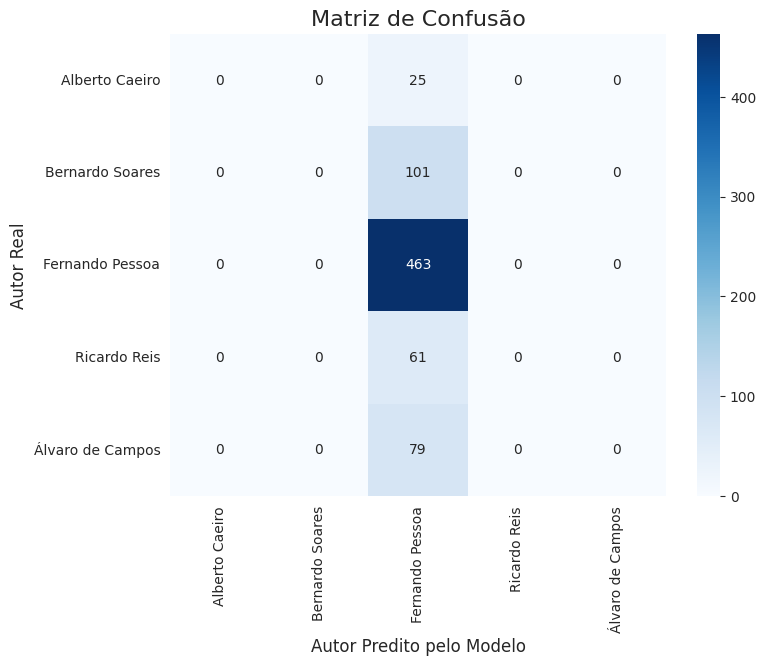

In [ ]:
print("\n--- AVALIAÇÃO DO MODELO NAIVE BAYES ---")

# Acurácia Geral
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral: {accuracy:.2%}\n")

# Relatório de Classificação Detalhado
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matriz de Confusão Visual
print("Matriz de Confusão:")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão', fontsize=16)
plt.ylabel('Autor Real', fontsize=12)
plt.xlabel('Autor Predito pelo Modelo', fontsize=12)
plt.show()

## Treinamento e Avaliação do Modelo Regressão Logística
---

In [ ]:
# Separa a classe majoritária das minoritárias
df_majoritario = df[df['autor'] == 'Fernando Pessoa']
df_minoritarios = df[df['autor'] != 'Fernando Pessoa']

In [ ]:
# Determina o tamanho da segunda maior classe (Bernardo Soares)
n_samples = df['autor'].value_counts().iloc[1]
print(f"A classe majoritária ('Fernando Pessoa') será reduzida para {n_samples} amostras.")

A classe majoritária ('Fernando Pessoa') será reduzida para 503 amostras.


In [ ]:
# Faz o downsample da classe majoritária
df_majoritario_downsampled = resample(df_majoritario,
                                      replace=False,    # Não queremos repor amostras
                                      n_samples=n_samples, # O número de amostras alvo
                                      random_state=42)

# Junta o DataFrame majoritário reduzido com os minoritários
df_balanceado = pd.concat([df_majoritario_downsampled, df_minoritarios])

print("\nNova distribuição de classes para treinamento:")
print(df_balanceado['autor'].value_counts())


Nova distribuição de classes para treinamento:
autor
Fernando Pessoa     503
Bernardo Soares     503
Álvaro de Campos    393
Ricardo Reis        307
Alberto Caeiro      127
Name: count, dtype: int64


In [ ]:
# Preparação dos Novos Dados
X_bal = df_balanceado['texto_limpo']
y_bal_text = df_balanceado['autor']
y_bal = encoder.transform(y_bal_text) # Usamos o mesmo encoder de antes

# ATENÇÃO: Usamos o mesmo conjunto de teste original (X_test, y_test) para uma comparação justa!
X_train_bal, _, y_train_bal, _ = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

In [ ]:
# Treinamento do Pipeline
pipeline_lr_bal = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_df=0.95, min_df=3, max_features=10000)),
    ('clf', LogisticRegression(solver='liblinear', random_state=42)) # Sem class_weight
])

pipeline_lr_bal.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [ ]:
# Avaliação no conjunto de teste
y_pred_bal = pipeline_lr_bal.predict(X_test)


--- AVALIAÇÃO DO MODELO REGRESSÃO LOGÍSTICA ---
Acurácia Geral: 78.05%

Relatório de Classificação:
                  precision    recall  f1-score   support

  Alberto Caeiro       1.00      0.08      0.15        25
 Bernardo Soares       0.48      0.77      0.59       101
 Fernando Pessoa       0.90      0.79      0.84       463
    Ricardo Reis       0.82      0.90      0.86        61
Álvaro de Campos       0.73      0.86      0.79        79

        accuracy                           0.78       729
       macro avg       0.79      0.68      0.65       729
    weighted avg       0.82      0.78      0.78       729

Matriz de Confusão:


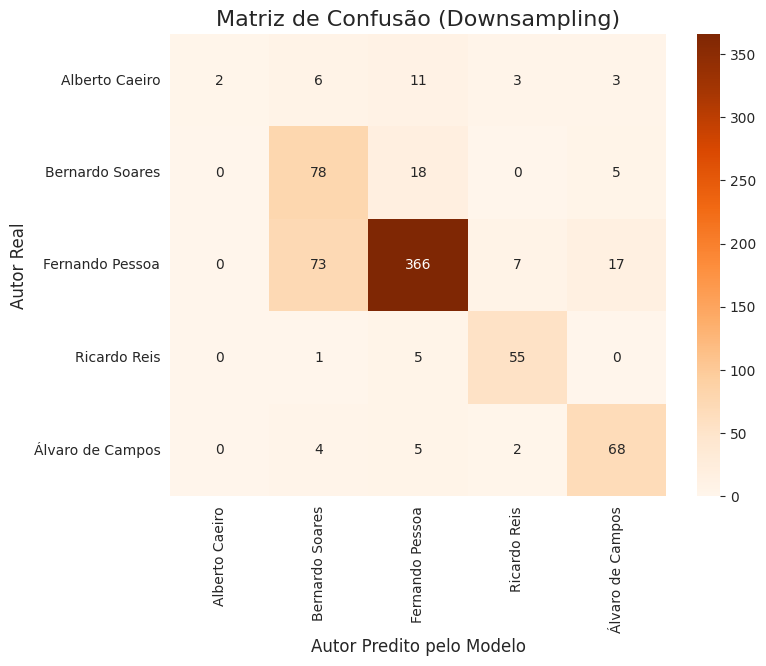

In [ ]:
print("\n--- AVALIAÇÃO DO MODELO REGRESSÃO LOGÍSTICA ---")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_bal):.2%}\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_bal, target_names=class_names))

print("Matriz de Confusão:")
conf_matrix_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bal, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Downsampling)', fontsize=16)
plt.ylabel('Autor Real', fontsize=12)
plt.xlabel('Autor Predito pelo Modelo', fontsize=12)
plt.show()

## Treinamento e Avaliação do Modelo SVM
---

In [ ]:
# Criamos um pipeline que primeiro vetoriza o texto com TF-IDF (usando os mesmos parâmetros
# dos modelos anteriores para consistência) e depois aplica o classificador SVC.
# - kernel='linear': Altamente eficaz para problemas de classificação de texto.
# - probability=True: Permite que o modelo calcule probabilidades de classe, útil para análises mais aprofundadas.
# - random_state=42: Garante a reprodutibilidade dos resultados.
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_df=0.95, min_df=3, max_features=10000)),
    ('clf', SVC(kernel='linear', probability=True, random_state=42))
])

In [ ]:
# O modelo é treinado com o conjunto de dados balanceado por downsampling (X_train_bal).
pipeline_svm.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf',
                 SVC(kernel='linear', probability=True, random_state=42))])

In [ ]:
# As predições são feitas no conjunto de teste original (X_test) para uma avaliação justa.
y_pred_svm = pipeline_svm.predict(X_test)


--- AVALIAÇÃO DO MODELO SVM ---
Acurácia Geral: 77.37%

Relatório de Classificação:
                  precision    recall  f1-score   support

  Alberto Caeiro       0.85      0.44      0.58        25
 Bernardo Soares       0.53      0.75      0.62       101
 Fernando Pessoa       0.92      0.75      0.83       463
    Ricardo Reis       0.75      0.95      0.84        61
Álvaro de Campos       0.61      0.94      0.74        79

        accuracy                           0.77       729
       macro avg       0.73      0.77      0.72       729
    weighted avg       0.82      0.77      0.78       729

Matriz de Confusão:


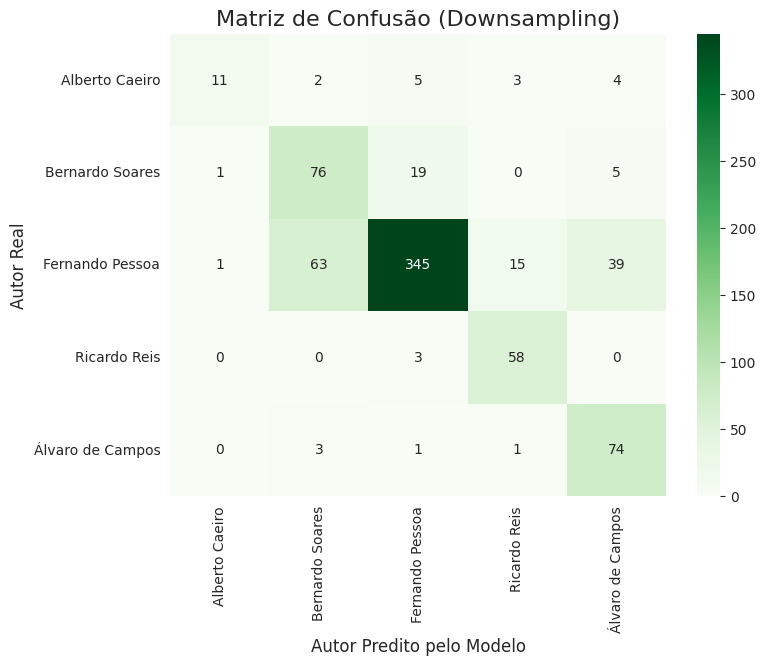

In [ ]:
print("\n--- AVALIAÇÃO DO MODELO SVM ---")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_svm):.2%}\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

print("Matriz de Confusão:")
conf_matrix_bal = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bal, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Downsampling)', fontsize=16)
plt.ylabel('Autor Real', fontsize=12)
plt.xlabel('Autor Predito pelo Modelo', fontsize=12)
plt.show()